In [ ]:
from theoretical_error_the_dumb_version import RegimeConfig, sample_t_from_regimes
from qiskit.quantum_info import SparsePauliOp
import numpy as np
from sympy import im, latex, Matrix # for latex display
from IPython.display import display, Math
import sys
sys.path



## Inputs and models

Given:
- alpha: the L1 norm of Hamiltonian weights, alpha = sum_j |h_j|
- m: number of QPE ancilla qubits
- N: qDRIFT sampling parameter
- total_samples: how many t-values you want to draw in total

The two component bounds you will visualize are:
- qDRIFT channelization bound
  $$
  E_{\mathrm{qDRIFT}}(t) \;=\; \frac{2\,\alpha^2}{N^2}\; t\; e^{\frac{2\alpha}{N} t}.
  $$
- QPE phase-resolution bound
  $$
  E_{\mathrm{QPE}}(t) \;=\; \frac{2\pi}{2^m}\cdot\frac{1}{t}.
  $$

Useful composites:
- Additive sum
  $$
  E_{\mathrm{sum}}(t) \;=\; E_{\mathrm{qDRIFT}}(t) + E_{\mathrm{QPE}}(t).
  $$
- Smooth “max-like” surrogate
  $$
  E_{\mathrm{rms}}(t) \;=\; \sqrt{\,E_{\mathrm{qDRIFT}}(t)^2 + E_{\mathrm{QPE}}(t)^2\,}.
  $$

These two mechanisms move in opposite directions as a function of $t$: $E_{\mathrm{QPE}}(t)\propto 1/t$ decays with $t$, while $E_{\mathrm{qDRIFT}}(t)\propto t\,e^{(2\alpha/N)t}$ grows with $t$. This tension induces three natural regimes.

---

## Three regimes (definition and boundaries)

We define a clean dominance threshold with a ratio parameter $\rho \ge 1$ (default $\rho=3$):

- QPE-dominated if
  $$
  E_{\mathrm{QPE}}(t) \;\ge\; \rho\; E_{\mathrm{qDRIFT}}(t),
  $$
- qDRIFT-dominated if
  $$
  E_{\mathrm{qDRIFT}}(t) \;\ge\; \rho\; E_{\mathrm{QPE}}(t),
  $$
- Crossover otherwise.

Let $B := \dfrac{2\pi}{2^m}$ and $c := \dfrac{2\alpha}{N}$. Setting the two components equal gives the balance point $t^\star$:
$$
\frac{2\,\alpha^2}{N^2}\, t^2\, e^{\frac{2\alpha}{N} t} \;=\; B
\quad\Longleftrightarrow\quad
\frac{2\,\alpha^2}{N^2}\, t^2\, e^{c t} \;=\; B.
$$
The two regime edges are defined by scaling the right-hand side by $\rho$:
- QPE-to-crossover (left) edge:
  $$
  \frac{2\,\alpha^2}{N^2}\, t^2\, e^{c t} \;=\; \frac{B}{\rho},
  $$
- Crossover-to-qDRIFT (right) edge:
  $$
  \frac{2\,\alpha^2}{N^2}\, t^2\, e^{c t} \;=\; B\,\rho.
  $$

Each left-hand side is strictly increasing in $t$ for $t>0$, so each equation admits a unique positive solution. Numerically we solve them with a bracketed 1D root finder (e.g., Brent).

Interpretation of the three $t$-regions:
- $t \le t_{\mathrm{QPE\,edge}}$: QPE-dominated (readout resolution dominates).
- $t_{\mathrm{QPE\,edge}} < t < t_{\mathrm{qDRIFT\,edge}}$: crossover (comparable contributions).
- $t \ge t_{\mathrm{qDRIFT\,edge}}$: qDRIFT-dominated (channelization dominates).

---

## Function 1: plot the curves with shaded regimes

What it does:
- Computes the three landmark times $\{t_{\mathrm{QPE\,edge}},\,t^\star,\,t_{\mathrm{qDRIFT\,edge}}\}$.
- Builds a logarithmic $t$-grid around them.
- Plots, on log–log axes:
  - $E_{\mathrm{QPE}}(t)$,
  - $E_{\mathrm{qDRIFT}}(t)$,
  - $E_{\mathrm{sum}}(t)$,
  - $E_{\mathrm{rms}}(t)$.
- Shades the three regimes using the two edges and marks the balance time $t^\star$ with a vertical reference line.

How to read the plot:
- The left shaded band shows where $E_{\mathrm{QPE}}$ is larger by at least a factor $\rho$.
- The center band shows the crossover, where neither effect is overwhelmingly larger.
- The right shaded band shows where $E_{\mathrm{qDRIFT}}$ is larger by at least a factor $\rho$.

---

## Function 2: sample random t’s from each regime

What it does:
- Uses the same three landmark times to define three intervals.
- Allocates the desired total number of samples approximately evenly across the three regimes (with automatic redistribution if any interval degenerates or is absent).
- Draws $t$ values log-uniformly within each regime interval (to fairly cover orders of magnitude).
- Returns the concatenation (sorted), together with the intervals, quotas, and the landmark times.

Why log-uniform?
- Because one component grows approximately exponentially in $t$ while the other decays algebraically, log-uniform sampling distributes points sensibly across the wide dynamic range within each regime.

---

## Minimal usage recipe (step-by-step)

1) Pick inputs $(\alpha, m, N)$ and a dominance ratio $\rho$ (e.g., $\rho=3$).

2) Call the plotting function to see the shapes and regime shading:
- It returns $\{t_{\mathrm{QPE\,edge}},\,t^\star,\,t_{\mathrm{qDRIFT\,edge}}\}$ and the $t$-domain used.

3) Call the sampling function with a desired total number of samples:
- It returns a sorted array of sampled times across the three regimes, plus a dictionary describing the intervals used and how many points were drawn in each.

4) Run your simulator at the sampled times and compare the observed error per $t$ to the four curves for validation.

---

## Why this partition is practical

- It is faithful to the explicit error forms you are validating:
  - a readout-resolution term $E_{\mathrm{QPE}}(t)\sim 1/t$,
  - a channelization term $E_{\mathrm{qDRIFT}}(t)\sim t\,e^{(2\alpha/N)t}$.
- The thresholds are defined by an interpretable ratio $\rho$ and solved with a monotone, uniquely solvable scalar equation.
- It yields a transparent workflow: visualize, identify regimes, randomly sample within each regime, and validate your implementation against the predicted shapes.

---

## Side note: hierarchical “fine vs coarse” viewpoint

If you want to frame this in a broader verification-and-validation mindset, think of the “sum” and “surrogate” curves as coarser, tractable descriptions, and a more detailed simulation (or an experiment) as a fine datum. You can then compare your coarser predictions against the datum and adapt how you allocate samples across regimes to control the discrepancy—an approach consistent with hierarchical modeling and a posteriori error control in computational science [1, 2].

---

## References

[1] <a href="https://doi.org/10.1016/s0045-7825(01)00256-0" target="_blank">Modeling error and adaptivity in nonlinear continuum mechanics, J.Tinsley Oden;Serge Prudhomme;Daniel C. Hammerand;Mieczyslaw S. Kuczma</a>  
[2] <a href="https://doi.org/10.1016/j.cma.2003.06.003" target="_blank">Theory and methodology for estimation and control of errors due to modeling, approximation, and and uncertainty, J. Tinsley Oden;Ivo Babuška;Fabio Nobile;Yusheng Feng;Raul Tempone</a>


In [63]:
hamiltonians = {
    "H_many_diag_terms_1" : SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([1/10, 2/10, 3/10, 4/10])),
    "H_many_diag_terms_3" : SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([4/5, 2/3, 4/5, 4/5])),
    "H_many_diag_terms_0.5" : SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([2/20, 1/20, 3/20, 4/20]))
}
lamda_lst = []
for ham_name, ham in hamiltonians.items():
    # display(Math(latex(Matrix(H_one_diag_term))+ latex(Matrix(eigenvector_direct))))
    display(Math(latex(Matrix(ham))))
    eigvals, _ = np.linalg.eig(ham.to_matrix())
    print("highest eigenvalue:", np.max(eigvals).real)
    lamdaa   = np.sum(np.abs(ham.coeffs))
    print("lambda:", lamdaa)
    lamda_lst.append(lamdaa)


<IPython.core.display.Math object>

highest eigenvalue: 1.0
lambda: 1.0


<IPython.core.display.Math object>

highest eigenvalue: 3.0666666666666664
lambda: 3.0666666666666664


<IPython.core.display.Math object>

highest eigenvalue: 0.5
lambda: 0.5


## How small is too small?
we want our phase to be less than the qpe uncertainty (duh)
Assuming $\lambda > 0$,

$$
\lambda t > \frac{1}{2^m t}

\implies \lambda t^2 > \frac{1}{2^m}

\implies t > \sqrt{\frac{1}{2^m \lambda}}

$$

In [ ]:
num_ancilla = 13
t_mins = [np.sqrt(1 / (2**(num_ancilla ) * lam)) for lam in lamda_lst]

cfgs = [
RegimeConfig(dominance_ratio=3,
                   t_min_search=t_min,
                   t_max_search=0.4,
                   grid_points_for_plot=100000,
                   random_seed=42) for t_min in t_mins
]

for cfg in cfgs:
    print(f"searching for regime boundaries in t ∈ [{cfg.t_min_search}, {cfg.t_max_search}]")
    

searching for regime boundaries in t ∈ [0.03125, 0.4]
searching for regime boundaries in t ∈ [0.017845007522505025, 0.4]
searching for regime boundaries in t ∈ [0.04419417382415922, 0.4]


Plotting for H_many_diag_terms_1 with alpha=1.0


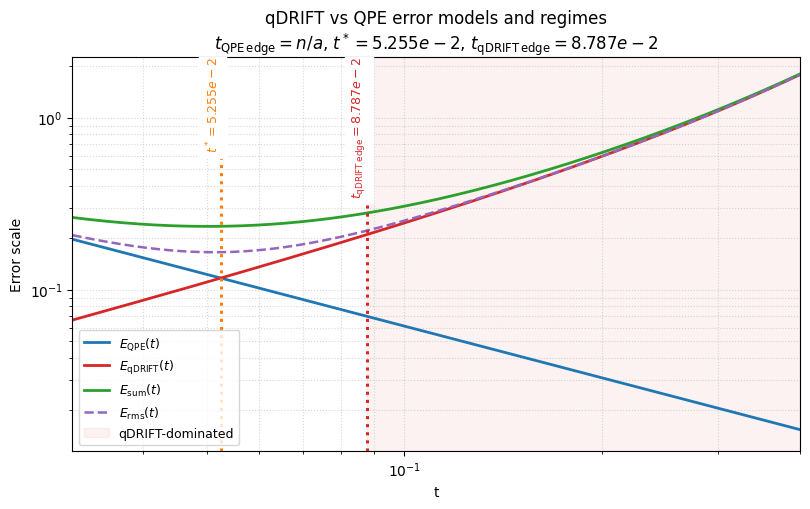

t_samples: [0.09679038 0.10134825 0.10669751 0.12399433 0.15413367 0.17088754
 0.17206637 0.17389418 0.20364433 0.23315231 0.25284664 0.27850558
 0.28396843 0.28922786 0.30577049 0.32283771 0.35797622 0.38549059]
intervals: {'qpe_dominated': None, 'crossover': None, 'qdrift_dominated': (0.08786693181896411, 0.4)}
edges: {'t_qpe_edge': None, 't_star': 0.05255345610032992, 't_qd_edge': 0.08786693181896411}
domain: (np.float64(0.03125), 0.4)
quotas: {'qpe_dominated': 0, 'crossover': 0, 'qdrift_dominated': 18}


Plotting for H_many_diag_terms_3 with alpha=3.0666666666666664


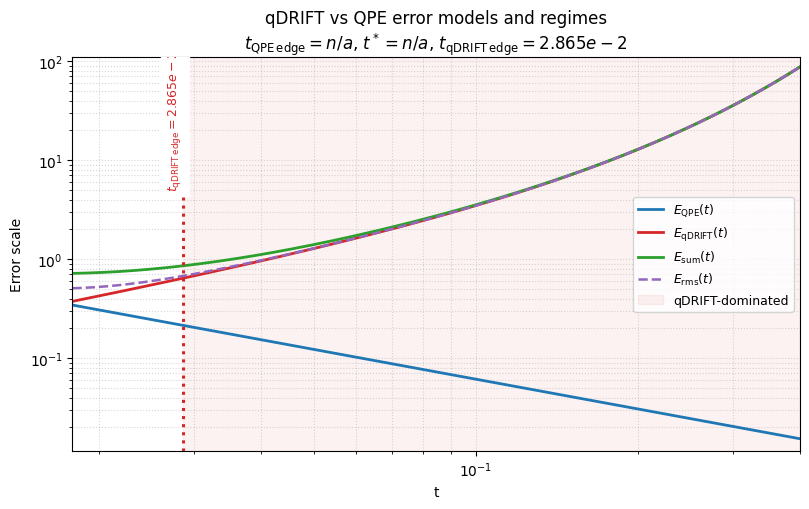

t_samples: [0.03390185 0.03672676 0.04016394 0.05215846 0.07615281 0.09112369
 0.09221983 0.09393042 0.12362424 0.15643026 0.18012596 0.21310251
 0.2204256  0.22757512 0.25069148 0.27552981 0.32977152 0.37510253]
intervals: {'qpe_dominated': None, 'crossover': None, 'qdrift_dominated': (0.028652260375750093, 0.4)}
edges: {'t_qpe_edge': None, 't_star': None, 't_qd_edge': 0.028652260375750093}
domain: (np.float64(0.017845007522505025), 0.4)
quotas: {'qpe_dominated': 0, 'crossover': 0, 'qdrift_dominated': 18}


Plotting for H_many_diag_terms_0.5 with alpha=0.5


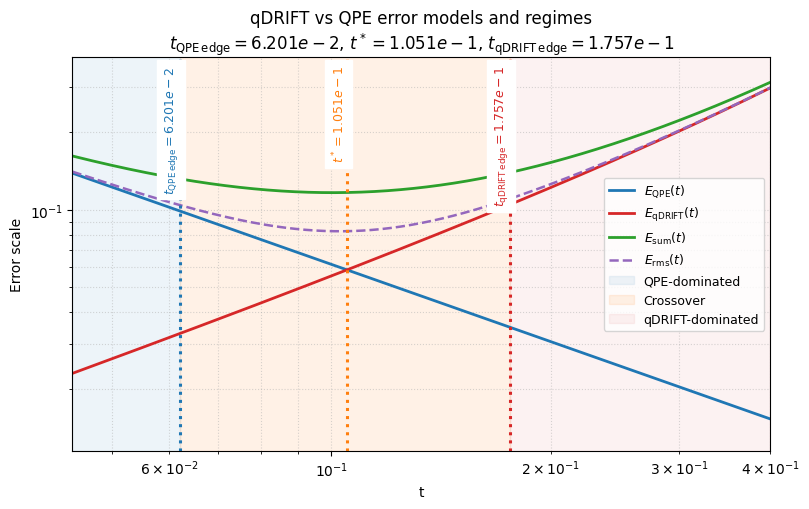

t_samples: [0.0456263  0.05127535 0.05596589 0.05743635 0.05910643 0.07085849
 0.09124067 0.09912794 0.13702158 0.14062596 0.17132723 0.18520439
 0.21184887 0.25307254 0.2773037  0.29843311 0.34574001 0.37661717]
intervals: {'qpe_dominated': (np.float64(0.04419417382415922), 0.06200547080427229), 'crossover': (0.06200547080427229, 0.17573386363792837), 'qdrift_dominated': (0.17573386363792837, 0.4)}
edges: {'t_qpe_edge': 0.06200547080427229, 't_star': 0.10510691220065857, 't_qd_edge': 0.17573386363792837}
domain: (np.float64(0.04419417382415922), 0.4)
quotas: {'qpe_dominated': 5, 'crossover': 6, 'qdrift_dominated': 7}




In [72]:
from math import e
i = 0
for h_name, hamiltonian in hamiltonians.items():
    alpha = np.sum(np.abs(hamiltonian.coeffs))
    print(f"Plotting for {h_name} with alpha={alpha}")
    cfg = cfgs[i]
    i += 1

    t_values = sample_t_from_regimes(alpha=alpha,
                                     m=num_ancilla,
                                     N=1,
                                     total_samples=18,
                                     cfg=cfg,
                                     sampling_allocation=(5, 6, 7))
    for key, value in t_values.items():
        print(f"{key}: {value}")

    print("\n")


In [66]:
# qdrift unfriendly
hamiltonians = {
    "H_many_diag_terms_1" : SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([2/10, -2/10, 3/10, -3/10])),
    "H_many_diag_terms_3" : SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([4/5, -2/3, 4/5, 4/5])),
    "H_many_diag_terms_0.5" : SparsePauliOp(data=["ZI", "ZZ", "IZ", "II"], coeffs=np.array([2/20, 1/20, 3/20, 4/20]))
}

lamda_lst = []
for ham_name, ham in hamiltonians.items():
    # display(Math(latex(Matrix(H_one_diag_term))+ latex(Matrix(eigenvector_direct))))
    display(Math(latex(Matrix(ham))))
    eigvals, _ = np.linalg.eig(ham.to_matrix())
    print("highest eigenvalue:", np.max(eigvals).real)
    lamdaa   = np.sum(np.abs(ham.coeffs))
    print("lambda:", lamdaa)
    lamda_lst.append(lamdaa)

<IPython.core.display.Math object>

highest eigenvalue: 0.0
lambda: 1.0


<IPython.core.display.Math object>

highest eigenvalue: 1.7333333333333334
lambda: 3.0666666666666664


<IPython.core.display.Math object>

highest eigenvalue: 0.5
lambda: 0.5
